# Numerical Linear Algebra — Notebook 2: QR Factorization and Least Squares

**Topics covered:** Projections · QR Factorization · Gram-Schmidt Orthogonalization · Householder Triangularization · Least Squares Problems

**Prerequisites:** Notebook 1 (Fundamentals — norms, orthogonal matrices, SVD)


In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False})


---
## 1. Projections

### Motivation

Projection is the geometric operation that underlies QR factorization, least squares,
and the analysis of iterative methods.
Understanding projectors precisely is essential before analyzing Gram-Schmidt and Householder.

### Definition

A linear map $P : \mathbb{R}^m \to \mathbb{R}^m$ is a **projector** if $P^2 = P$.

It is an **orthogonal projector** if additionally $P = P^{\top}$.

### Orthogonal Projection onto a Subspace

If the columns of $A \in \mathbb{R}^{m \times n}$ form a basis for a subspace $S$, the orthogonal projector onto $S$ is:

$$P = A(A^{\top}A)^{-1}A^{\top}.$$

The complementary projector $I - P$ projects onto $S^\perp = \operatorname{null}(A^{\top})$.

For a single unit vector $\hat{q}$: $P = \hat{q}\hat{q}^{\top}$.

### Orthogonality of the Residual

For any $b \in \mathbb{R}^m$, the residual $b - Pb$ is orthogonal to the range of $P$:

$$P^{\top}(b - Pb) = P(b - Pb) = Pb - P^2 b = 0.$$

This is the geometric foundation of least squares.

### Key Identities

- $P^2 = P$ (idempotent)
- $P = P^{\top}$ (symmetric, for orthogonal projectors)
- $\operatorname{range}(P) \perp \operatorname{range}(I-P)$
- $\|Px\|_2 \le \|x\|_2$ (projection never increases norm)


In [2]:
# Build orthogonal projector onto column space of A and verify properties
np.random.seed(1)
m, k = 8, 3
A = np.random.randn(m, k)

# Orthogonal projector onto col(A)
P = A @ np.linalg.solve(A.T @ A, A.T)

print("Orthogonal projector onto col(A):")
print(f"  Idempotent P^2 = P:      ||P^2 - P||_F = {np.linalg.norm(P @ P - P, 'fro'):.2e}")
print(f"  Symmetric P = P^T:       ||P - P^T||_F = {np.linalg.norm(P - P.T, 'fro'):.2e}")

# Eigenvalues of an orthogonal projector are 0 and 1
eigvals = np.linalg.eigvalsh(P)
print(f"  Eigenvalues: min={eigvals.min():.4f}, max={eigvals.max():.4f}  (should be 0 and 1)")
print(f"  Rank of P = {round(np.linalg.matrix_rank(P))} = k = {k}  (projects onto k-dim subspace)")

# Residual orthogonality
b = np.random.randn(m)
Pb  = P @ b
res = b - Pb
print(f"\n  ||P^T (b - Pb)||_2 = {np.linalg.norm(P.T @ res):.2e}  (residual orthogonal to range(P))")
print(f"  ||Pb||_2 <= ||b||_2: {np.linalg.norm(Pb):.6f} <= {np.linalg.norm(b):.6f}")


Orthogonal projector onto col(A):
  Idempotent P^2 = P:      ||P^2 - P||_F = 4.24e-16
  Symmetric P = P^T:       ||P - P^T||_F = 2.67e-16
  Eigenvalues: min=-0.0000, max=1.0000  (should be 0 and 1)
  Rank of P = 3 = k = 3  (projects onto k-dim subspace)

  ||P^T (b - Pb)||_2 = 2.45e-16  (residual orthogonal to range(P))
  ||Pb||_2 <= ||b||_2: 1.405501 <= 1.777256


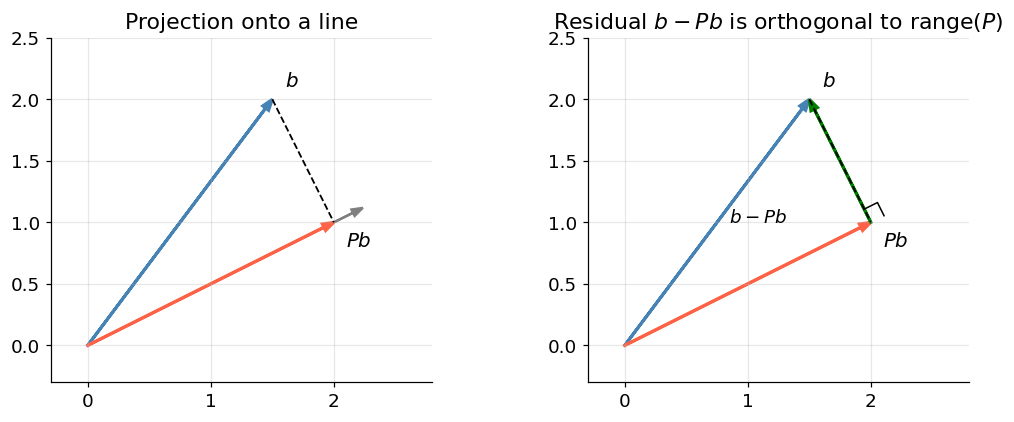

In [3]:
# Geometric visualization of projection in R^2
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: projection onto a line (1D subspace)
v = np.array([2., 1.]); v = v / np.linalg.norm(v)
P_line = np.outer(v, v)
b = np.array([1.5, 2.0])
Pb = P_line @ b
res = b - Pb

ax = axes[0]
ax.arrow(0, 0, v[0]*2.5, v[1]*2.5, head_width=0.06, color='gray', lw=1.5, length_includes_head=True)
ax.arrow(0, 0, b[0],  b[1],  head_width=0.06, color='steelblue', lw=2, length_includes_head=True)
ax.arrow(0, 0, Pb[0], Pb[1], head_width=0.06, color='tomato',    lw=2, length_includes_head=True)
ax.plot([b[0], Pb[0]], [b[1], Pb[1]], 'k--', lw=1.2)
ax.annotate('$b$',  xy=b,  fontsize=13, xytext=b  + [0.1, 0.1])
ax.annotate('$Pb$', xy=Pb, fontsize=13, xytext=Pb + [0.1,-0.2])
ax.set_xlim(-0.3, 2.8); ax.set_ylim(-0.3, 2.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title('Projection onto a line')

# Right: show that residual is orthogonal to subspace
ax = axes[1]
ax.arrow(0, 0, b[0],  b[1],  head_width=0.06, color='steelblue', lw=2, length_includes_head=True)
ax.arrow(0, 0, Pb[0], Pb[1], head_width=0.06, color='tomato',    lw=2, length_includes_head=True)
ax.arrow(Pb[0], Pb[1], res[0], res[1], head_width=0.06, color='green', lw=2, length_includes_head=True)
ax.plot([b[0], Pb[0]], [b[1], Pb[1]], 'k--', lw=1.2)
ax.annotate('$b$',     xy=b,  fontsize=13, xytext=b  + [0.1, 0.1])
ax.annotate('$Pb$',    xy=Pb, fontsize=13, xytext=Pb + [0.1,-0.2])
ax.annotate('$b-Pb$',  xy=(Pb+res)/2+[0.1,0], fontsize=12)
angle_marker = 0.12
ax.plot([Pb[0]+angle_marker*(-v[1]), Pb[0]+angle_marker*(-v[1]+v[0]),
         Pb[0]+angle_marker*v[0]],
        [Pb[1]+angle_marker*v[0],  Pb[1]+angle_marker*(v[0]+v[1]),
         Pb[1]+angle_marker*v[1]], 'k-', lw=1)
ax.set_xlim(-0.3, 2.8); ax.set_ylim(-0.3, 2.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title('Residual $b - Pb$ is orthogonal to range$(P)$')

plt.tight_layout()
plt.show()


---
## 2. QR Factorization

### Theorem

Every $A \in \mathbb{R}^{m \times n}$ with $m \ge n$ has a **full QR factorization**:

$$A = QR, \quad Q \in \mathbb{R}^{m \times m} \text{ orthogonal},\quad R \in \mathbb{R}^{m \times n} \text{ upper triangular}.$$

If $A$ has full column rank, the **thin (reduced) QR** $A = \hat{Q}\hat{R}$ is unique
when the diagonal of $\hat{R}$ is required to be positive,
with $\hat{Q} \in \mathbb{R}^{m \times n}$ having orthonormal columns and $\hat{R} \in \mathbb{R}^{n \times n}$.

### Relation to the SVD

The QR factorization does not directly reveal singular values, but it is the preferred route to:

- Solving overdetermined least squares problems stably.
- Computing eigenvalues via the QR algorithm.
- Orthonormal bases for subspaces.

### Why QR and Not LU?

LU factorization is $O(n^3/3)$ and perfect for square systems $Ax = b$.
For overdetermined systems ($m \gg n$) and for stability, QR is preferred:
orthogonal transformations never amplify errors.


In [4]:
# Full and thin QR via NumPy
np.random.seed(2)
m, n = 7, 4
A = np.random.randn(m, n)

Q_full, R_full = np.linalg.qr(A, mode='complete')   # full QR
Q_thin, R_thin = np.linalg.qr(A, mode='reduced')    # thin QR

print(f"Full QR:  Q is {Q_full.shape}, R is {R_full.shape}")
print(f"Thin QR:  Q is {Q_thin.shape}, R is {R_thin.shape}")
print()
print(f"Full QR reconstruction error: {np.linalg.norm(Q_full @ R_full - A, 'fro'):.2e}")
print(f"Thin QR reconstruction error: {np.linalg.norm(Q_thin @ R_thin - A, 'fro'):.2e}")
print()
print(f"Q_full orthogonality: ||Q^T Q - I||_F = {np.linalg.norm(Q_full.T @ Q_full - np.eye(m), 'fro'):.2e}")
print(f"Q_thin orthonormality: ||Q^T Q - I||_F = {np.linalg.norm(Q_thin.T @ Q_thin - np.eye(n), 'fro'):.2e}")
print()
print("R (thin) diagonal entries (should all be positive for unique QR):")
print(np.diag(R_thin))


Full QR:  Q is (7, 7), R is (7, 4)
Thin QR:  Q is (7, 4), R is (4, 4)

Full QR reconstruction error: 2.23e-15
Thin QR reconstruction error: 2.23e-15

Q_full orthogonality: ||Q^T Q - I||_F = 1.19e-15
Q_thin orthonormality: ||Q^T Q - I||_F = 9.13e-16

R (thin) diagonal entries (should all be positive for unique QR):
[ 2.32321469  1.71877031 -2.27253083 -3.27200786]


---
## 3. Gram-Schmidt Orthogonalization

### Overview

Gram-Schmidt converts a basis into an orthonormal one by sequentially projecting out all components
in the directions already orthogonalized. It directly constructs the thin QR factorization.

### Classical Gram-Schmidt (CGS)

Given linearly independent $a_1, \ldots, a_n \in \mathbb{R}^m$:

$$\tilde{q}_j = a_j - \sum_{i=1}^{j-1} (q_i^{\top} a_j)\, q_i, \qquad q_j = \frac{\tilde{q}_j}{\|\tilde{q}_j\|_2}.$$

The QR coefficients are $r_{ij} = q_i^{\top} a_j$ (for $i < j$) and $r_{jj} = \|\tilde{q}_j\|_2$.

### Modified Gram-Schmidt (MGS)

MGS reorders the orthogonalization to subtract projections one at a time:

For each $j = 1, \ldots, n$:
1. Set $v^{(j)} = a_j$.
2. For $i = 1, \ldots, j-1$: $r_{ij} = q_i^{\top} v^{(j)}$, then $v^{(j)} \leftarrow v^{(j)} - r_{ij} q_i$.
3. $r_{jj} = \|v^{(j)}\|_2$, $q_j = v^{(j)} / r_{jj}$.

CGS and MGS are **algebraically identical** but differ dramatically in floating-point arithmetic.
In MGS, the updated vector $v^{(j)}$ becomes progressively more orthogonal to previous $q_i$'s
before the next subtraction, preventing the accumulation of errors that afflicts CGS.

### Loss of Orthogonality

CGS can completely lose orthogonality when the input columns are nearly linearly dependent.
Specifically, $\|Q^{\top}Q - I\|_F$ can grow to $O(\varepsilon_{\text{mach}} \kappa(A))$ for CGS
versus $O(\varepsilon_{\text{mach}})$ for Householder (which is the standard for backward stability).


In [5]:
def cgs(A):
    'Classical Gram-Schmidt returning thin QR factors.'
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            R[i, j] = Q[:, i] @ A[:, j]
            v = v - R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]
    return Q, R

def mgs(A):
    'Modified Gram-Schmidt returning thin QR factors.'
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    V = A.copy().astype(float)
    for j in range(n):
        R[j, j] = np.linalg.norm(V[:, j])
        Q[:, j] = V[:, j] / R[j, j]
        for k in range(j+1, n):
            R[j, k] = Q[:, j] @ V[:, k]
            V[:, k] = V[:, k] - R[j, k] * Q[:, j]
    return Q, R

# Correctness check on a well-conditioned matrix
np.random.seed(5)
A = np.random.randn(8, 5)
Q_cgs, R_cgs = cgs(A)
Q_mgs, R_mgs = mgs(A)
Q_np,  R_np  = np.linalg.qr(A, mode='reduced')

print("Well-conditioned matrix (random 8x5):")
for name, Q, R in [("CGS", Q_cgs, R_cgs), ("MGS", Q_mgs, R_mgs), ("NumPy", Q_np, R_np)]:
    orth_err = np.linalg.norm(Q.T @ Q - np.eye(5), 'fro')
    rec_err  = np.linalg.norm(Q @ R - A, 'fro')
    print(f"  {name}: ||Q^T Q - I||_F = {orth_err:.2e},  ||QR - A||_F = {rec_err:.2e}")


Well-conditioned matrix (random 8x5):
  CGS: ||Q^T Q - I||_F = 3.88e-16,  ||QR - A||_F = 6.08e-16
  MGS: ||Q^T Q - I||_F = 4.19e-16,  ||QR - A||_F = 5.23e-16
  NumPy: ||Q^T Q - I||_F = 5.03e-16,  ||QR - A||_F = 1.20e-15


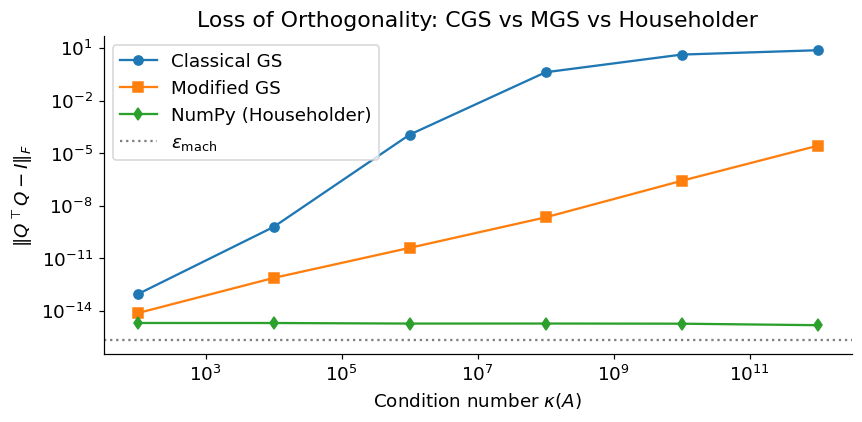

Conclusion: CGS loses orthogonality proportionally to kappa(A).
MGS is significantly better. Householder (used by NumPy) maintains
near-machine-epsilon orthogonality regardless of conditioning.


In [6]:
# Loss of orthogonality: CGS vs MGS on an ill-conditioned matrix
def build_ill_conditioned(m, n, kappa):
    'Construct a matrix with prescribed condition number kappa.'
    U, _ = np.linalg.qr(np.random.randn(m, n))
    s = np.logspace(0, -np.log10(kappa), n)
    V, _ = np.linalg.qr(np.random.randn(n, n))
    return (U * s) @ V.T

kappas = [1e2, 1e4, 1e6, 1e8, 1e10, 1e12]
orth_cgs, orth_mgs, orth_np = [], [], []

m, n = 50, 20
for kappa in kappas:
    np.random.seed(99)
    A = build_ill_conditioned(m, n, kappa)
    Q_c, _ = cgs(A)
    Q_m, _ = mgs(A)
    Q_n, _ = np.linalg.qr(A, mode='reduced')
    orth_cgs.append(np.linalg.norm(Q_c.T @ Q_c - np.eye(n), 'fro'))
    orth_mgs.append(np.linalg.norm(Q_m.T @ Q_m - np.eye(n), 'fro'))
    orth_np.append( np.linalg.norm(Q_n.T @ Q_n - np.eye(n), 'fro'))

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(kappas, orth_cgs, 'o-', label='Classical GS')
ax.loglog(kappas, orth_mgs, 's-', label='Modified GS')
ax.loglog(kappas, orth_np,  'd-', label='NumPy (Householder)')
ax.axhline(np.finfo(float).eps, ls=':', color='gray', label=r'$\varepsilon_{\rm mach}$')
ax.set_xlabel(r'Condition number $\kappa(A)$')
ax.set_ylabel(r'$\|Q^\top Q - I\|_F$')
ax.set_title('Loss of Orthogonality: CGS vs MGS vs Householder')
ax.legend()
plt.tight_layout()
plt.show()

print("Conclusion: CGS loses orthogonality proportionally to kappa(A).")
print("MGS is significantly better. Householder (used by NumPy) maintains")
print("near-machine-epsilon orthogonality regardless of conditioning.")


---
## 4. Householder Triangularization

### Motivation

Householder triangularization achieves QR via a sequence of orthogonal reflections.
It is **backward stable** and never suffers the loss of orthogonality that can afflict Gram-Schmidt.
It is the algorithm used in LAPACK and NumPy.

### Householder Reflector

A Householder reflector is the orthogonal matrix:

$$H = I - 2vv^{\top}, \quad \|v\|_2 = 1, \quad H = H^{\top}, \quad H^2 = I.$$

It reflects any vector across the hyperplane $\{v\}^\perp$.
Given $x \in \mathbb{R}^m$, we choose $v$ so that:

$$Hx = \pm\|x\|_2\, e_1.$$

The sign is chosen **opposite** to the sign of $x_1$ to avoid catastrophic cancellation:

$$v = \frac{x + \operatorname{sign}(x_1)\|x\|_2 e_1}{\|x + \operatorname{sign}(x_1)\|x\|_2 e_1\|_2}.$$

### Triangularization Algorithm

At step $k = 1, \ldots, n$, apply $H^{(k)}$ to zero out entries below the diagonal in column $k$.
After $n$ steps (for $m \ge n$):

$$H^{(n)} \cdots H^{(1)} A = R \implies A = QR, \quad Q = H^{(1)} \cdots H^{(n)}.$$

**Cost:** Approximately $2mn^2 - \frac{2}{3}n^3$ flops.

**Backward stability:** The computed $\tilde{Q}, \tilde{R}$ satisfy $A + E = \tilde{Q}\tilde{R}$
where $\|E\|_2 = O(\varepsilon_{\text{mach}})\|A\|_2$. The loss of orthogonality is $\|\tilde{Q}^{\top}\tilde{Q} - I\|_F = O(\varepsilon_{\text{mach}})$.


In [7]:
def householder_vector(x):
    'Compute the Householder vector v such that H x = -sign(x[0])||x|| e_1.'
    v = x.copy().astype(float)
    sigma = np.linalg.norm(v)
    if sigma == 0:
        return v, 0.0
    # Choose sign to avoid cancellation
    v[0] += np.sign(x[0]) * sigma if x[0] != 0 else sigma
    beta = 2.0 / (v @ v)   # H = I - beta v v^T  (v not normalized)
    return v, beta

def householder_qr(A):
    'QR via Householder reflections. Returns Q and R.'
    m, n = A.shape
    R = A.copy().astype(float)
    Qs = []  # store (v, beta) pairs to reconstruct Q

    for k in range(n):
        v, beta = householder_vector(R[k:, k])
        if beta == 0:
            continue
        # Apply H = I - beta v v^T from the left to R[k:, k:]
        R[k:, k:] -= beta * np.outer(v, v @ R[k:, k:])
        Qs.append((k, v, beta))

    # Build Q explicitly by accumulating reflections
    Q = np.eye(m)
    for (k, v, beta) in reversed(Qs):
        Q[k:, k:] -= beta * np.outer(v, v @ Q[k:, k:])

    return Q[:, :n], np.triu(R[:n, :])  # thin QR

# Test
np.random.seed(6)
m, n = 8, 5
A = np.random.randn(m, n)

Q_hh, R_hh = householder_qr(A)
Q_np, R_np  = np.linalg.qr(A, mode='reduced')

print("Householder QR vs NumPy QR:")
print(f"  ||Q_HH R_HH - A||_F  = {np.linalg.norm(Q_hh @ R_hh - A, 'fro'):.2e}")
print(f"  ||Q_HH^T Q_HH - I||_F = {np.linalg.norm(Q_hh.T @ Q_hh - np.eye(n), 'fro'):.2e}")
print(f"  ||Q_NP^T Q_NP - I||_F = {np.linalg.norm(Q_np.T @ Q_np - np.eye(n), 'fro'):.2e}")


Householder QR vs NumPy QR:
  ||Q_HH R_HH - A||_F  = 2.92e-15
  ||Q_HH^T Q_HH - I||_F = 7.92e-16
  ||Q_NP^T Q_NP - I||_F = 4.00e-16


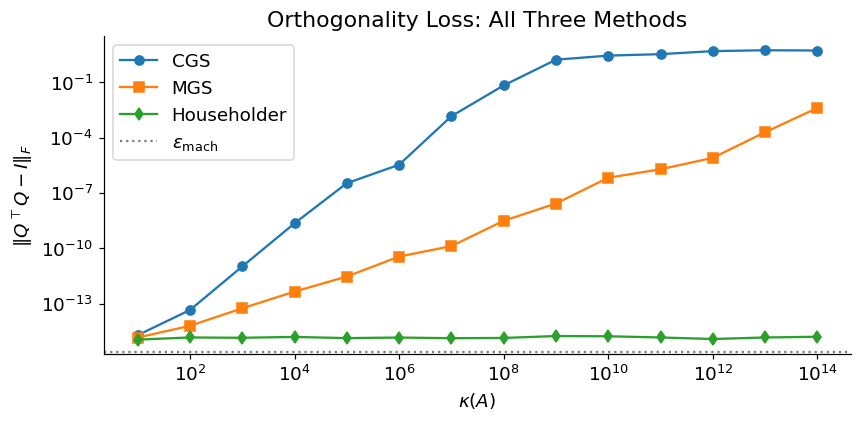

In [8]:
# Compare orthogonality: CGS vs MGS vs Householder as condition number grows
kappas_log = np.arange(1, 15)
kappas = 10.0 ** kappas_log
m, n = 40, 15
orth_cgs2, orth_mgs2, orth_hh2 = [], [], []

for kappa in kappas:
    np.random.seed(77)
    A = build_ill_conditioned(m, n, kappa)
    Q_c, _ = cgs(A)
    Q_m, _ = mgs(A)
    Q_h, _ = householder_qr(A)
    orth_cgs2.append(np.linalg.norm(Q_c.T @ Q_c - np.eye(n), 'fro'))
    orth_mgs2.append(np.linalg.norm(Q_m.T @ Q_m - np.eye(n), 'fro'))
    orth_hh2.append( np.linalg.norm(Q_h.T @ Q_h - np.eye(n), 'fro'))

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(kappas, orth_cgs2, 'o-', label='CGS')
ax.loglog(kappas, orth_mgs2, 's-', label='MGS')
ax.loglog(kappas, orth_hh2,  'd-', label='Householder')
ax.axhline(np.finfo(float).eps, ls=':', color='gray', label=r'$\varepsilon_{\rm mach}$')
ax.set_xlabel(r'$\kappa(A)$')
ax.set_ylabel(r'$\|Q^\top Q - I\|_F$')
ax.set_title('Orthogonality Loss: All Three Methods')
ax.legend()
plt.tight_layout()
plt.show()


---
## 5. Least Squares Problems

### Problem Statement

Given $A \in \mathbb{R}^{m \times n}$ ($m \ge n$) and $b \in \mathbb{R}^m$, find:

$$x^* = \arg\min_{x \in \mathbb{R}^n} \|Ax - b\|_2^2.$$

If $A$ has full column rank, there is a unique solution.

### Three Solution Approaches

**1. Normal equations**

The first-order optimality condition gives:

$$A^{\top}Ax = A^{\top}b.$$

This is a symmetric positive definite system (when $A$ has full column rank),
solvable by Cholesky. **Problem:** $\kappa(A^{\top}A) = \kappa(A)^2$, squaring the condition number.

**2. QR factorization**

With $A = \hat{Q}\hat{R}$ (thin QR):

$$\|Ax - b\|_2^2 = \|\hat{R}x - \hat{Q}^{\top}b\|_2^2 + \|(I - \hat{Q}\hat{Q}^{\top})b\|_2^2.$$

Solve the triangular system $\hat{R}x = \hat{Q}^{\top}b$ by back-substitution.
Condition number of $\hat{R}$ is $\kappa(A)$, not $\kappa(A)^2$.

**3. SVD**

With $A = U\Sigma V^{\top}$ (thin SVD):

$$x^* = V\Sigma^+ U^{\top} b = \sum_{i=1}^{n} \frac{u_i^{\top} b}{\sigma_i} v_i.$$

Most expensive but most informative: reveals sensitivity to individual singular values.
Essential when $A$ is rank-deficient or near rank-deficient.


In [9]:
def solve_ls_normal(A, b):
    'Least squares via normal equations (Cholesky on A^T A).'
    ATA = A.T @ A
    ATb = A.T @ b
    return np.linalg.solve(ATA, ATb)

def solve_ls_qr(A, b):
    'Least squares via thin QR factorization.'
    Q, R = np.linalg.qr(A, mode='reduced')
    return la.solve_triangular(R, Q.T @ b, lower=False)

def solve_ls_svd(A, b):
    'Least squares via thin SVD (minimum-norm solution).'
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return Vt.T @ ((U.T @ b) / s)

# Overdetermined system: polynomial fitting
m, n = 60, 8
t = np.linspace(-1, 1, m)
# Vandermonde matrix for polynomial of degree n-1
A = np.vander(t, n, increasing=True)
# True signal + noise
x_true = np.random.randn(n)
b = A @ x_true + 0.1 * np.random.randn(m)

x_normal = solve_ls_normal(A, b)
x_qr     = solve_ls_qr(A, b)
x_svd    = solve_ls_svd(A, b)
x_ref    = np.linalg.lstsq(A, b, rcond=None)[0]

print("Least squares solution comparison (polynomial fit, 60 pts, degree 7):")
print(f"  Normal equations: ||x - x_ref||_2 = {np.linalg.norm(x_normal - x_ref):.2e}")
print(f"  QR method:        ||x - x_ref||_2 = {np.linalg.norm(x_qr    - x_ref):.2e}")
print(f"  SVD method:       ||x - x_ref||_2 = {np.linalg.norm(x_svd   - x_ref):.2e}")
print()
print(f"  Residual norms:")
for name, x in [("Normal", x_normal), ("QR", x_qr), ("SVD", x_svd)]:
    print(f"    {name}: ||Ax - b||_2 = {np.linalg.norm(A @ x - b):.6f}")


Least squares solution comparison (polynomial fit, 60 pts, degree 7):
  Normal equations: ||x - x_ref||_2 = 8.76e-12
  QR method:        ||x - x_ref||_2 = 8.28e-15
  SVD method:       ||x - x_ref||_2 = 1.18e-14

  Residual norms:
    Normal: ||Ax - b||_2 = 0.704121
    QR: ||Ax - b||_2 = 0.704121
    SVD: ||Ax - b||_2 = 0.704121


Condition number of A:   kappa(A)    = 1.00e+08
Condition number of A^T A:           = 1.07e+16



C:\Users\abdallah\AppData\Local\Temp\ipykernel_32376\1042570019.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([errs['Normal Eqs.'], errs['QR'], errs['SVD']],


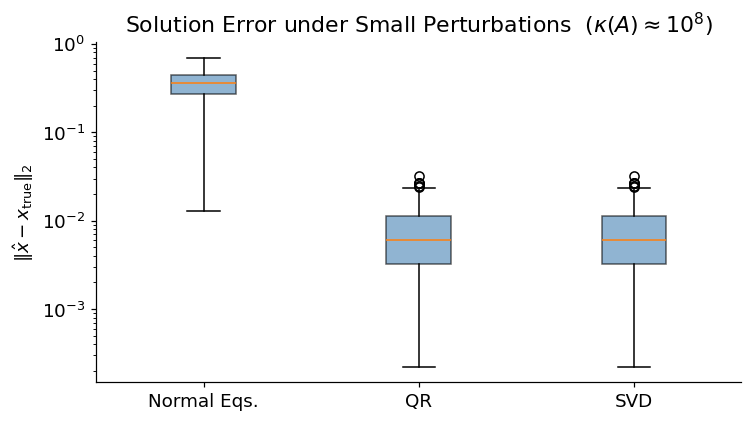

With kappa(A) ~ 1e8, kappa(A^T A) ~ 1e16 nearly exhausts double precision.
QR and SVD remain stable; normal equations can lose significant digits.


In [10]:
# Sensitivity analysis: perturb b and compare accuracy of each method
np.random.seed(3)
m, n = 50, 10
kappa_target = 1e8
A_ill = build_ill_conditioned(m, n, kappa_target)
x_true = np.random.randn(n)
b = A_ill @ x_true

kappa_A = np.linalg.cond(A_ill)
print(f"Condition number of A:   kappa(A)    = {kappa_A:.2e}")
print(f"Condition number of A^T A:           = {np.linalg.cond(A_ill.T @ A_ill):.2e}")
print()

n_trials = 500
errs = {'Normal Eqs.': [], 'QR': [], 'SVD': []}
for _ in range(n_trials):
    db = 1e-10 * np.random.randn(m)
    bp = b + db
    try:
        x_n = solve_ls_normal(A_ill, bp)
        errs['Normal Eqs.'].append(np.linalg.norm(x_n - x_true))
    except np.linalg.LinAlgError:
        pass
    errs['QR'].append(np.linalg.norm(solve_ls_qr(A_ill, bp) - x_true))
    errs['SVD'].append(np.linalg.norm(solve_ls_svd(A_ill, bp) - x_true))

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([errs['Normal Eqs.'], errs['QR'], errs['SVD']],
           labels=['Normal Eqs.', 'QR', 'SVD'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_yscale('log')
ax.set_ylabel(r'$\|\hat{x} - x_{\rm true}\|_2$')
ax.set_title(r'Solution Error under Small Perturbations  ($\kappa(A) \approx 10^8$)')
plt.tight_layout()
plt.show()

print("With kappa(A) ~ 1e8, kappa(A^T A) ~ 1e16 nearly exhausts double precision.")
print("QR and SVD remain stable; normal equations can lose significant digits.")


Fitted coefficients: [ 6.62022628 -8.28986576  2.59180289]
True  coefficients: [4.1, -7.3, 2.5]
Residual ||Ax-b||_2 = 136.3361


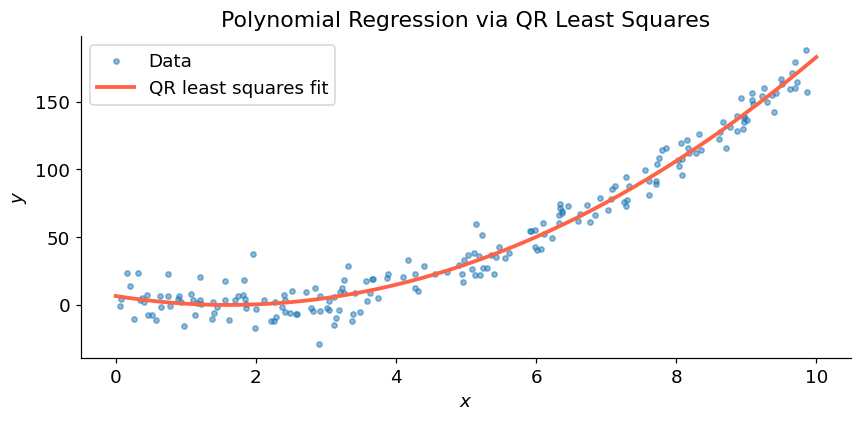

In [11]:
# Practical example: linear regression on real-scale data
np.random.seed(42)
n_pts = 200
x_data = np.random.uniform(0, 10, n_pts)
y_true = 2.5 * x_data**2 - 7.3 * x_data + 4.1
y_data = y_true + 10 * np.random.randn(n_pts)

# Build Vandermonde matrix for degree-2 polynomial
A_reg = np.vander(x_data, 3, increasing=True)  # columns: 1, x, x^2
coeffs = solve_ls_qr(A_reg, y_data)

print(f"Fitted coefficients: {coeffs}")
print(f"True  coefficients: [4.1, -7.3, 2.5]")
print(f"Residual ||Ax-b||_2 = {np.linalg.norm(A_reg @ coeffs - y_data):.4f}")

x_plot = np.linspace(0, 10, 300)
A_plot = np.vander(x_plot, 3, increasing=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x_data, y_data, s=12, alpha=0.5, label='Data')
ax.plot(x_plot, A_plot @ coeffs, 'tomato', lw=2.5, label='QR least squares fit')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Polynomial Regression via QR Least Squares')
ax.legend()
plt.tight_layout()
plt.show()


---
## Section Summary

| Method | Cost | Condition number seen | Recommended when |
|---|---|---|---|
| Normal equations | $O(mn^2 + n^3/3)$ | $\kappa(A)^2$ | $A$ is very well-conditioned |
| QR factorization | $O(2mn^2 - 2n^3/3)$ | $\kappa(A)$ | Standard workhorse |
| SVD | $O(mn^2 + n^3)$ or more | $\kappa(A)$ | Near rank-deficient, need pseudoinverse |

**The QR approach to least squares is the numerical standard.** It avoids squaring the condition number
(which the normal equations do) while being cheaper than the full SVD.
When the problem is near rank-deficient, SVD with truncation is the only reliable tool.
